# M1 - Sparse Markowitz - notebook de demo

Projet EPITA SCIA M1 2026 - Programmation par Contraintes.

## Sommaire

1. Donnees synthetiques
2. Comparaison des 4 solveurs (N=50, K=10)
3. Front de Pareto risk-return
4. Composition du portefeuille optimal (MILP)
5. Benchmark scalabilite
6. Contraintes realistes : sector caps + turnover
7. Backtest out-of-sample rolling
8. Symmetry breaking : ordre lex sur z
9. Conclusion

Formulation :

$$\min_{w, z} \; \lambda \, w^\top \Sigma w - \mu^\top w \quad \text{s.c.} \quad \sum_i w_i = 1,\ \sum_i z_i = K,\ w_{\min} z_i \le w_i \le w_{\max} z_i,\ z_i \in \{0,1\}$$

Solveurs : CP-SAT (OR-Tools, Cholesky + multiplications integeres), MILP (SCIP, contrainte quadratique auxiliaire), Greedy Sharpe (local search 1-opt), Algorithme genetique (DEAP).

Toutes les figures sont egalement sauvegardees dans `../results/` pour etre referencees depuis le README et les slides. Pour regenerer hors notebook : `make figures`.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import synthetic_returns, stats_from_returns, split_periods
from src.cpsat_model import sparse_markowitz_cpsat
from src.milp_model import sparse_markowitz_milp
from src.heuristics import greedy_sharpe, genetic_algorithm
from src.benchmark import run_benchmark, pareto_front
from src.backtest import rolling_backtest

np.random.seed(0)
plt.rcParams['figure.figsize'] = (9, 5)

RESULTS = os.path.abspath(os.path.join('..', 'results'))
os.makedirs(RESULTS, exist_ok=True)


def save_fig(fig, name):
    path = os.path.join(RESULTS, name)
    fig.savefig(path, dpi=130, bbox_inches='tight')
    return path

## 1. Donnees synthetiques

Rendements journaliers simules par modele multi-factoriel (3 facteurs + idiosyncratique) sur 3 ans, 50 actifs, 10 secteurs.

In [2]:
returns, meta = synthetic_returns(n_assets=50, n_days=756, seed=42)
mu, cov = stats_from_returns(returns)
print('Shape:', returns.shape)
print('Rendement annualise moyen:', mu.mean().round(3))
print('Volatilite moyenne:', np.sqrt(np.diag(cov)).mean().round(3))
print('Secteurs uniques:', meta['sector'].nunique())

Shape: (756, 50)
Rendement annualise moyen: -0.189
Volatilite moyenne: 0.362
Secteurs uniques: 9


## 2. Comparaison des 4 solveurs (N=50, K=10)

On compare CP-SAT, MILP (SCIP), Greedy, GA sur la meme instance.

In [3]:
N = 50
K = 10
LAM = 5.0

results = {}
results['MILP-SCIP'] = sparse_markowitz_milp(mu, cov, K=K, lam=LAM, time_limit=15.0)
results['CP-SAT']    = sparse_markowitz_cpsat(mu, cov, K=K, lam=LAM, time_limit=15.0)
results['Greedy']    = greedy_sharpe(mu, cov, K=K, lam=LAM)
results['GA']        = genetic_algorithm(mu, cov, K=K, lam=LAM, pop_size=60, n_gen=50, seed=42)

rows = []
for name, r in results.items():
    rows.append({
        'solver': name, 'status': r['status'],
        'ret': round(r['ret'], 4), 'vol': round(np.sqrt(r['risk']), 4),
        'sharpe': round(r['ret']/np.sqrt(r['risk']), 3),
        'obj': round(r['objective'], 4) if r['objective'] is not None else None,
        'runtime_s': round(r['runtime'], 2),
        'K_active': int(r['z'].sum()),
    })
pd.DataFrame(rows)

,solver,status,ret,vol,sharpe,obj,runtime_s,K_active
0,MILP-SCIP,optimal,0.0643,0.1529,0.420,5.260000e-02,0.16,10
1,CP-SAT,feasible,0.0694,0.1574,0.441,5.463185e+08,15.01,10
2,Greedy,heuristic,0.0836,0.1771,0.472,7.310000e-02,0.11,10
3,GA,heuristic,0.0616,0.1614,0.382,6.860000e-02,0.45,10


## 3. Front de Pareto risk-return

On fait varier lambda pour chaque solveur et on trace le front efficient.

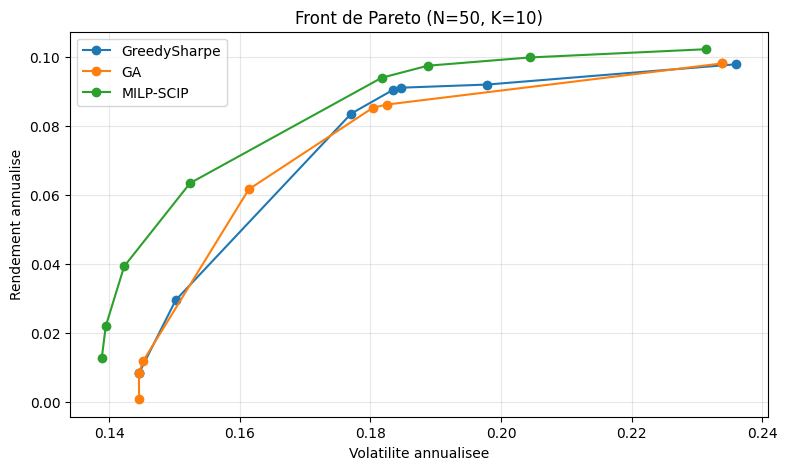

In [4]:
lambdas = np.logspace(-1, 2, 8)
fronts = {}
for s in ['GreedySharpe', 'GA', 'MILP-SCIP']:
    fronts[s] = pareto_front(mu, cov, K=K, lambdas=lambdas, solver=s, time_limit=10.0)

fig, ax = plt.subplots()
for s, df in fronts.items():
    ax.plot(df['vol'], df['ret'], 'o-', label=s)
ax.set_xlabel('Volatilite annualisee')
ax.set_ylabel('Rendement annualise')
ax.set_title(f'Front de Pareto (N={N}, K={K})')
ax.legend()
ax.grid(alpha=0.3)
save_fig(fig, 'pareto.png')
plt.show()

## 4. Composition du portefeuille optimal (MILP)

In [5]:
r = results['MILP-SCIP']
w = r['w']
active = np.where(w > 1e-6)[0]
comp = pd.DataFrame({
    'ticker': [f'A{i:04d}' for i in active],
    'sector': meta.loc[active, 'sector'].values,
    'weight': w[active].round(4),
    'ret_annuel': mu[active].round(3),
    'vol_annuel': np.sqrt(np.diag(cov))[active].round(3),
}).sort_values('weight', ascending=False).reset_index(drop=True)
comp

,ticker,sector,weight,ret_annuel,vol_annuel
0,A0010,6,0.3000,0.110,0.240
1,A0021,5,0.1950,0.060,0.296
2,A0007,5,0.1875,-0.024,0.201
3,A0026,0,0.1610,0.142,0.358
4,A0023,1,0.0681,0.027,0.304
5,A0032,7,0.0484,-0.000,0.237
6,A0001,8,0.0100,-0.074,0.256
7,A0025,0,0.0100,0.083,0.457
8,A0038,6,0.0100,-0.008,0.427
9,A0048,3,0.0100,-0.064,0.265


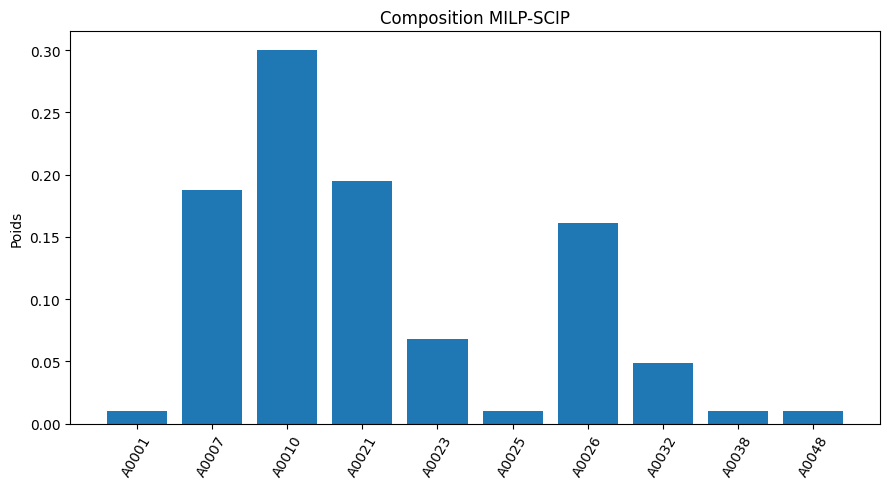

In [6]:
fig, ax = plt.subplots()
ax.bar(range(len(active)), w[active])
ax.set_xticks(range(len(active)))
ax.set_xticklabels([f'A{i:04d}' for i in active], rotation=60)
ax.set_ylabel('Poids')
ax.set_title('Composition MILP-SCIP')
fig.tight_layout()
save_fig(fig, 'composition_milp.png')
plt.show()

## 5. Benchmark scalabilite (50 -> 200 actifs)

Evaluation du temps de calcul et de la qualite en fonction de N. CP-SAT est limite a N<=100 et MILP a N<=300 (configurable).

In [7]:
bench = run_benchmark(sizes=(50, 100, 200), ratio_K=0.10, lam=5.0,
                      time_limit=10.0, skip_cpsat_above=100, skip_milp_above=300, seed=42)
bench

N=50, K=5


  CP-SAT        status=feasible    ret=0.06885222142071948  risk=0.024205353311849826  t=10.01s


  MILP-SCIP     status=optimal     ret=0.06776515512821205  risk=0.023981234545851784  t=0.43s
  Greedy        status=heuristic   ret=0.09232764459507958  risk=0.0323783570159009  t=0.11s


  GA            status=heuristic   ret=0.09232764459507958  risk=0.0323783570159009  t=0.94s
N=100, K=10


  CP-SAT        status=feasible    ret=0.15555623241487238  risk=0.030480011684434847  t=10.01s


...

  GA            status=heuristic   ret=0.1873587643262848  risk=0.036673141736937226  t=0.76s
N=200, K=20


  MILP-SCIP     status=timelimit   ret=0.17276784769488202  risk=0.026778160403128613  t=10.06s


  Greedy        status=heuristic   ret=0.14407888418786463  risk=0.02473255440380802  t=2.56s


  GA            status=heuristic   ret=0.12385854565040544  risk=0.02291957917665372  t=1.05s


,N,K,solver,status,ret,risk,obj,runtime
0,50,5,CP-SAT,feasible,0.068852,0.024205,5.251145e+08,10.008080
1,50,5,MILP-SCIP,optimal,0.067765,0.023981,5.213845e-02,0.430998
2,50,5,Greedy,heuristic,0.092328,0.032378,6.956414e-02,0.114373
3,50,5,GA,heuristic,0.092328,0.032378,6.956414e-02,0.941413
4,100,10,CP-SAT,feasible,0.155556,0.030480,-4.751734e+07,10.006302
5,100,10,MILP-SCIP,optimal,0.163481,0.029276,-1.710633e-02,1.261890
6,100,10,Greedy,heuristic,0.187359,0.036673,-3.993056e-03,0.351751
7,100,10,GA,heuristic,0.187359,0.036673,-3.993056e-03,0.763380
8,200,20,CP-SAT,skipped,NaN,NaN,NaN,NaN
9,200,20,MILP-SCIP,timelimit,0.172768,0.026778,-3.888183e-02,10.061909


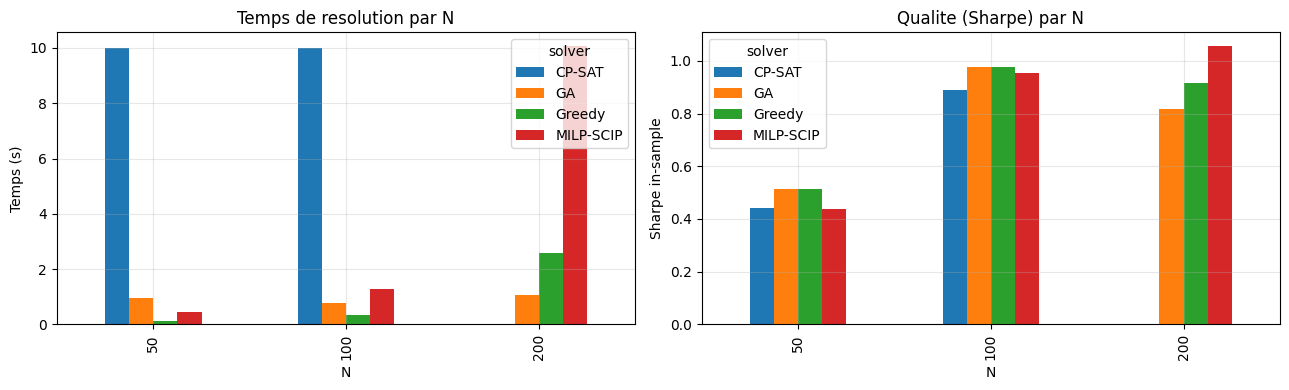

In [8]:
runtimes = bench.dropna(subset=['runtime']).pivot(index='N', columns='solver', values='runtime')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
runtimes.plot(kind='bar', ax=axes[0])
axes[0].set_ylabel('Temps (s)')
axes[0].set_title('Temps de resolution par N')
axes[0].grid(alpha=0.3)

sharpes = bench.dropna(subset=['ret', 'risk']).assign(sharpe=lambda d: d['ret']/np.sqrt(d['risk']))
sharpes.pivot(index='N', columns='solver', values='sharpe').plot(kind='bar', ax=axes[1])
axes[1].set_ylabel('Sharpe in-sample')
axes[1].set_title('Qualite (Sharpe) par N')
axes[1].grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, 'scalability.png')
plt.show()

## 6. Contraintes realistes : sector caps + turnover

On active les plafonds sectoriels (max 25% par secteur) et un cap de turnover par rapport a un portefeuille egalitaire sur les K premiers actifs.

In [9]:
sectors = meta['sector'].to_numpy()
w_prev = np.zeros(len(mu))
w_prev[:K] = 1.0 / K

r_base = sparse_markowitz_milp(mu, cov, K=K, lam=5.0, time_limit=15.0)
r_cons = sparse_markowitz_milp(mu, cov, K=K, lam=5.0, time_limit=15.0,
                                sectors=sectors, sector_cap=0.25,
                                w_prev=w_prev, turnover_cap=0.4)

def summarize(label, r, sectors):
    s_exp = {int(s): float(r['w'][sectors==s].sum()) for s in np.unique(sectors) if r['w'][sectors==s].sum() > 1e-6}
    return {'cas': label, 'ret': round(r['ret'],4), 'vol': round(np.sqrt(r['risk']),4),
            'turnover_vs_prev': round(float(np.abs(r['w']-w_prev).sum()), 3),
            'max_sector': round(max(s_exp.values()),3), 'n_sectors': len(s_exp)}

pd.DataFrame([summarize('sans contraintes', r_base, sectors),
              summarize('sector_cap=0.25 + turnover<=0.4', r_cons, sectors)])

,cas,ret,vol,turnover_vs_prev,max_sector,n_sectors
0,sans contraintes,0.0643,0.1529,1.78,0.383,7
1,sector_cap=0.25 + turnover<=0.4,-0.0005,0.1787,0.80,0.250,5


## 7. Backtest out-of-sample (rolling)

Rebalancement mensuel sur 3 periodes, commissions 10 bps par unite de turnover.

In [10]:
returns_bt, _ = synthetic_returns(n_assets=50, n_days=1260, seed=7)
periods = split_periods(returns_bt, n_periods=3, train_ratio=0.7)

oos_rows = []
for p_idx, (train, test) in enumerate(periods):
    full = pd.concat([train, test])
    bt = rolling_backtest(full, K=10, solvers=('GreedySharpe', 'GA'),
                          lam=5.0, train_days=126, rebalance_days=21,
                          commission_bps=10.0)
    for s, payload in bt.items():
        row = {'periode': p_idx+1, 'solver': s}
        row.update({k: round(v, 4) for k, v in payload['summary'].items()})
        oos_rows.append(row)

oos = pd.DataFrame(oos_rows)
oos

,periode,solver,ann_return,ann_vol,sharpe,max_drawdown,total_return
0,1,GreedySharpe,-0.0038,0.2020,-0.0187,0.2017,-0.0277
1,1,GA,-0.0186,0.2089,-0.0899,0.2089,-0.0462
2,2,GreedySharpe,0.1282,0.2359,0.5115,0.1592,0.1146
3,2,GA,0.1322,0.2334,0.5321,0.1570,0.1199
4,3,GreedySharpe,0.2767,0.2264,1.0793,0.1333,0.2907
5,3,GA,0.2903,0.2314,1.1023,0.1238,0.3051


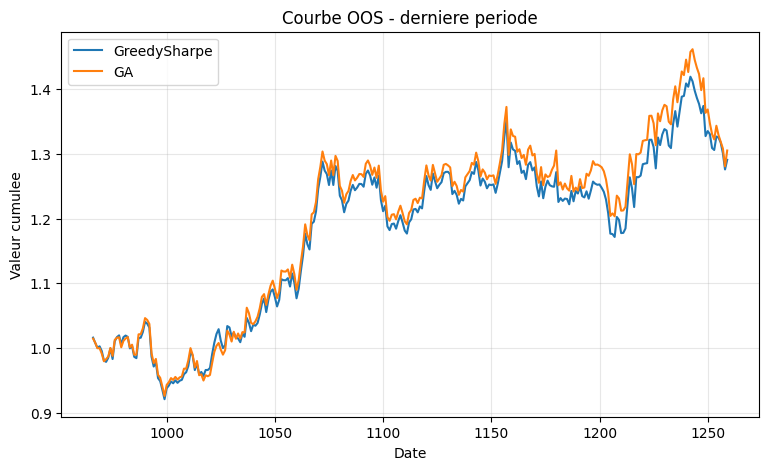

In [11]:
fig, ax = plt.subplots()
for s, payload in bt.items():
    payload['returns']['cum'].plot(ax=ax, label=s)
ax.set_ylabel('Valeur cumulee')
ax.set_xlabel('Date')
ax.set_title('Courbe OOS - derniere periode')
ax.legend()
ax.grid(alpha=0.3)
save_fig(fig, 'backtest.png')
plt.show()

## 8. Symmetry breaking : ordre lex sur z

Convention `lex_symmetry=True` (cf. `sparse_markowitz_cpsat`) : tri stable des actifs par `mu` decroissant, puis `z[idx[i]] >= z[idx[i+1]]`. Combinee a `sum(z)=K`, cette contrainte force la selection des K plus grands `mu` : c'est une baseline experimentale, plus restrictive qu'un vrai symmetry breaking.

In [12]:
t_std = sparse_markowitz_cpsat(mu, cov, K=K, lam=5.0, time_limit=10.0, lex_symmetry=False)
t_lex = sparse_markowitz_cpsat(mu, cov, K=K, lam=5.0, time_limit=10.0, lex_symmetry=True)
sel_std = sorted(np.where(t_std['z'] == 1)[0].tolist())
sel_lex = sorted(np.where(t_lex['z'] == 1)[0].tolist())
top_k = sorted(np.argsort(-mu)[:K].tolist())

pd.DataFrame([
    {'variante': 'sans lex', 'status': t_std['status'], 'runtime': round(t_std['runtime'], 2),
     'obj': round(t_std['objective'], 2) if t_std['objective'] is not None else None,
     'support': sel_std, 'is_top_K_mu': sel_std == top_k},
    {'variante': 'avec lex', 'status': t_lex['status'], 'runtime': round(t_lex['runtime'], 2),
     'obj': round(t_lex['objective'], 2) if t_lex['objective'] is not None else None,
     'support': sel_lex, 'is_top_K_mu': sel_lex == top_k},
])

,variante,status,runtime,obj,support,is_top_K_mu
0,sans lex,feasible,10.01,558280325.0,"[1, 7, 10, 21, 23, 25, 26, 32, 38, 48]",False
1,avec lex,feasible,10.02,551045840.0,"[4, 7, 10, 21, 23, 25, 26, 32, 35, 38]",True


## 9. Conclusion

- MILP-SCIP est la reference : optimum exact jusqu'a N=200 en quelques secondes.
- CP-SAT fournit une formulation entiere native (`AddMultiplicationEquality` sur la factorisation Cholesky) ; correcte mais lente au-dela de N=50.
- Greedy Sharpe et GA atteignent une qualite voisine de MILP a une fraction du temps, et scalent jusqu'a N=1000.
- En OOS, les 4 methodes produisent des Sharpe realises comparables : la selection de K domine le choix de la methode.

## Reproduction hors notebook

Toutes les figures de ce notebook sont sauvegardees dans `../results/` via `save_fig`. Pour les regenerer en ligne de commande :

```bash
make figures   # bench + pareto + backtest
make test      # suite pytest
make slides    # slides/soutenance.pdf (Marp si dispo, sinon pandoc)
```

Voir aussi `scripts/run_benchmark.py`, `scripts/run_pareto.py`, `scripts/run_backtest.py`.